In [1]:
import pandas as pd

df = pd.read_csv("../data/prices_demo.csv")
df["date"] = pd.to_datetime(df["date"])
df["price"] = pd.to_numeric(df["price"])
df = df.sort_values(["item","date"])

df["pct_change"] = df.groupby("item")["price"].pct_change() * 100
latest_date = df["date"].max()
latest = df[df["date"] == latest_date].copy()

latest[["item","price","pct_change"]]

,item,price,pct_change
5,oil,260,36.842105
2,rice,200,66.666667


In [2]:
SHOCK_THRESHOLD = 20
shocks = latest.dropna(subset=["pct_change"])
shocks = shocks[shocks["pct_change"].abs() >= SHOCK_THRESHOLD]
shocks

,date,item,price,pct_change
5,2026-01-01,oil,260,36.842105
2,2026-01-01,rice,200,66.666667


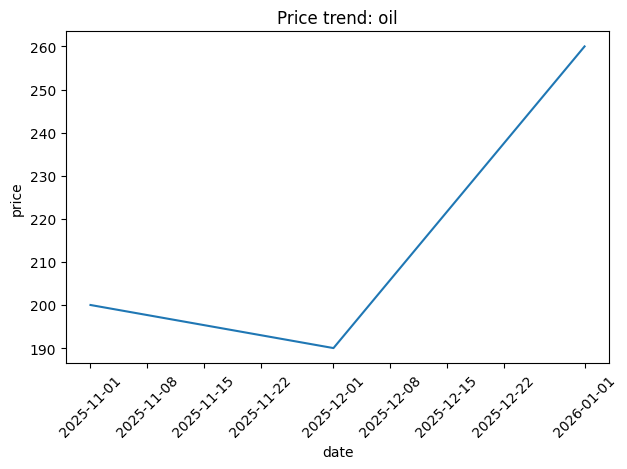

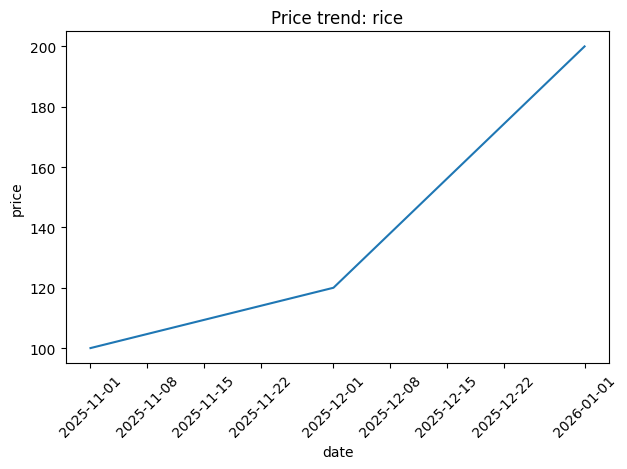

In [4]:
import matplotlib.pyplot as plt

for item, g in df.groupby("item"):
    plt.figure()
    plt.plot(g["date"], g["price"])
    plt.title(f"Price trend: {item}")
    plt.xlabel("date")
    plt.ylabel("price")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()